# CG Reconstruction Example

This notebook demonstrates compressed sensing reconstruction using the Conjugate Gradient (CG) method.

The CG reconstructor minimizes ChiSquared + regularization terms to recover sparse Faraday depth spectra.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from csromer.simulation import FaradayThinSource
from csromer.wrappers.reconstructors import CGReconstructorWrapper
from csromer.utils.array_utils import maybe_compute

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Create Test Source with Noise

In [2]:
# Create source
nu = np.linspace(1.0e9, 1.5e9, 128)
source = FaradayThinSource(
    nu=nu,
    s_nu=0.1,
    phi_gal=50.0,
    spectral_idx=-0.7,
)
source.simulate()

# Add noise
source.apply_noise(0.01, random_state=np.random.RandomState(42))

print(f"Source:")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")
print(f"  Flux: {source.s_nu:.3f} Jy")
print(f"  Channels: {len(nu)}")

Source:
  True RM: 50.00 rad/m²
  Flux: 0.100 Jy
  Channels: 128


## 2. Run CG Reconstruction

In [3]:
# Create reconstructor
recon = CGReconstructorWrapper(
    dataset=source,
    oversampling=4.0,
    cg_maxiter=30,
    cg_tol=1e-4,
    cg_verbose=True,  # Show progress
)

# Run reconstruction
recon.reconstruct()

print(f"\nReconstruction Results:")
print(f"  Dirty RM: {recon.rm_dirty:.2f} rad/m²")
print(f"  Model RM: {recon.rm_model:.2f} rad/m²")
print(f"  Restored RM: {recon.rm_restored:.2f} rad/m²")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")
print(f"\n  RM Error (model): {abs(recon.rm_model - source.phi_gal):.2f} rad/m²")
print(f"  RM Error (dirty): {abs(recon.rm_dirty - source.phi_gal):.2f} rad/m²")

FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.502
Starting Polak-Ribiere-Polyak (Conjugate Gradient)
Initial function value = 6618.013788
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Polak-Ribiere-Polyak converged after 28 iterations
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve] kernel len=15 sum=4.228633 max=1.000000 (max=1, peak-conserving)
  [convolve] input x is None=False  peak|data_np|=6.310545e-03  sum|data_np|=3.840127e-01
[restore DEBUG]
  cellsize=3.878083  rmtf_fwhm=15.405924  pix

## 3. Visualize Results

**Units (CLEAN/RML convention):**
- **Dirty** and **restored** are in **Jy/rmtf** (flux per unit RMTF).
- **Model** is in **Jy/phi_pixel** (flux per phi pixel). The optimizer works in Jy/phi_pixel and **starts from complex zeros** (not from the dirty map). Restored = convolved model (scaled to Jy/rmtf) + residual.
- So model amplitude is not directly comparable to dirty/restored on the same y-axis.

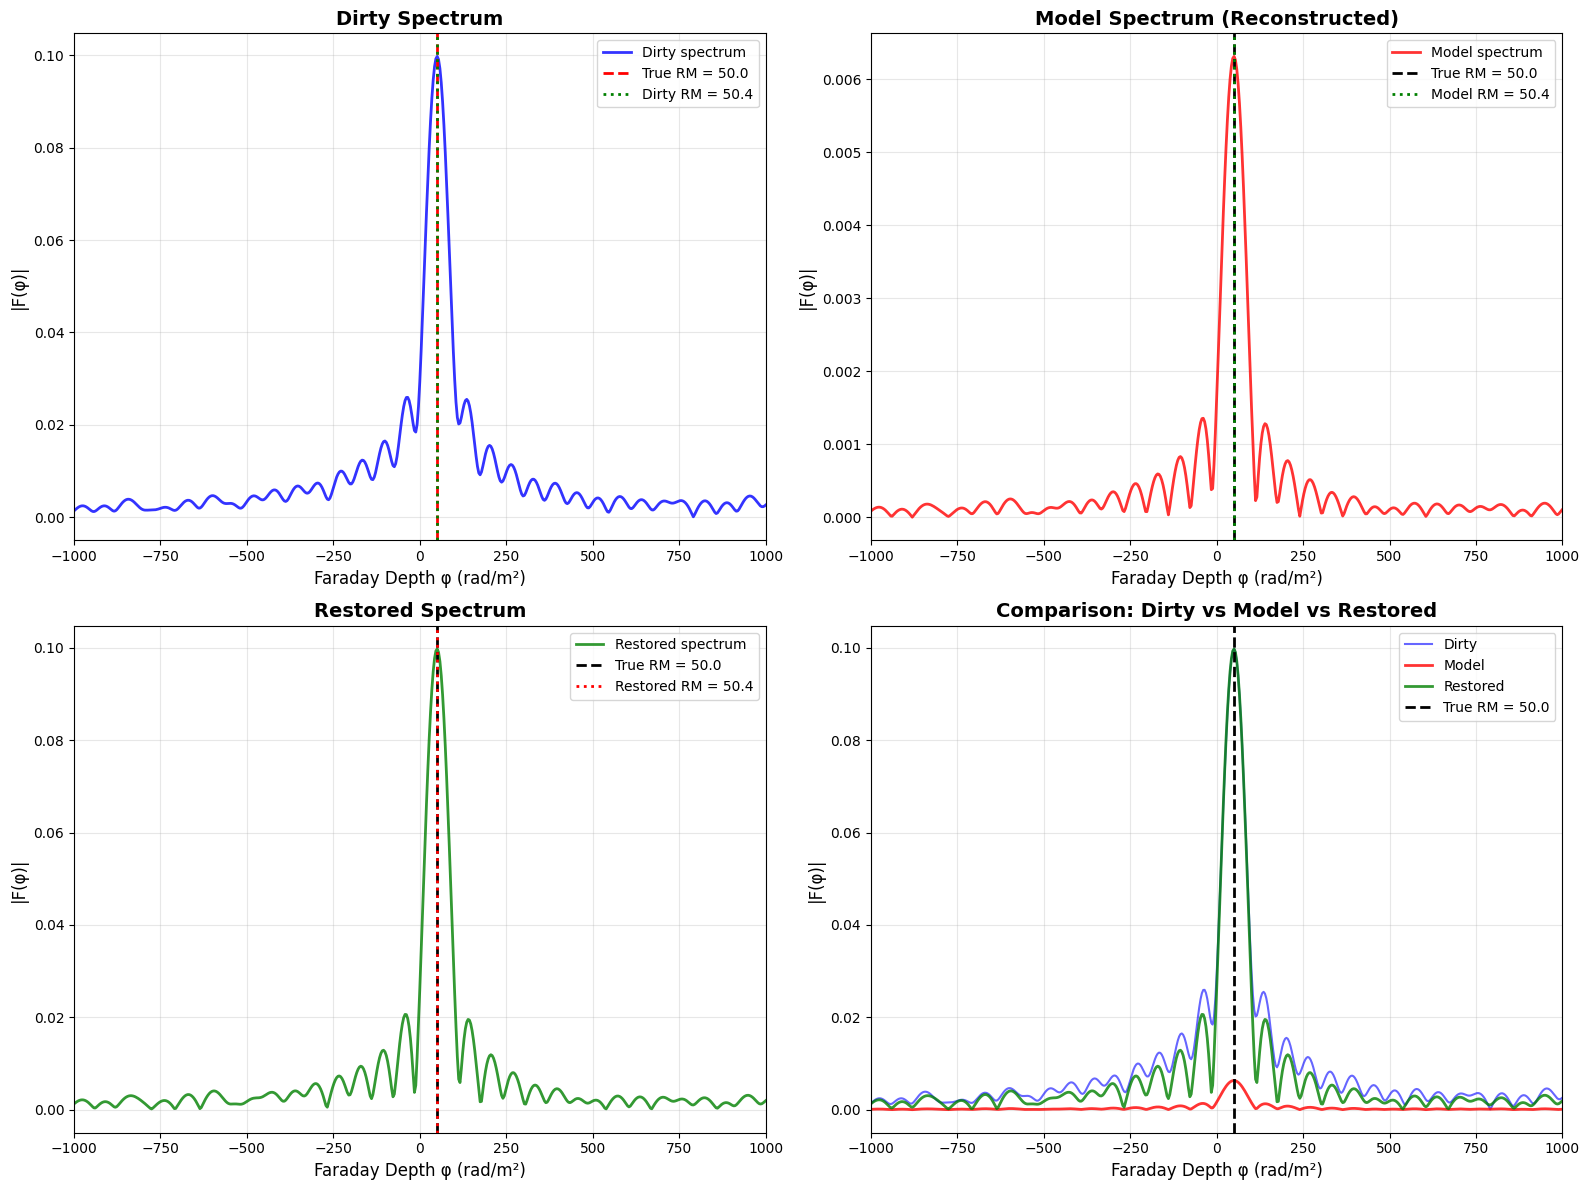

In [4]:
phi = np.asarray(maybe_compute(recon.parameter.phi))
fd_dirty = np.asarray(maybe_compute(recon.fd_dirty))
fd_model = np.asarray(maybe_compute(recon.fd_model))
fd_restored = np.asarray(maybe_compute(recon.fd_restored))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Dirty spectrum
ax = axes[0, 0]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=2, label='Dirty spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.axvline(recon.rm_dirty, color='g', linestyle=':', linewidth=2, label=f'Dirty RM = {recon.rm_dirty:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Dirty Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 2: Model spectrum
ax = axes[0, 1]
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.axvline(recon.rm_model, color='g', linestyle=':', linewidth=2, label=f'Model RM = {recon.rm_model:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Model Spectrum (Reconstructed)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 3: Restored spectrum
ax = axes[1, 0]
ax.plot(phi, np.abs(fd_restored), 'g-', linewidth=2, label='Restored spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.axvline(recon.rm_restored, color='r', linestyle=':', linewidth=2, label=f'Restored RM = {recon.rm_restored:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Restored Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 4: Comparison
ax = axes[1, 1]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=1.5, label='Dirty', alpha=0.6)
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model', alpha=0.8)
ax.plot(phi, np.abs(fd_restored), 'g-', linewidth=2, label='Restored', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Comparison: Dirty vs Model vs Restored', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

## 4. Quality Metrics

In [5]:
print("Quality Metrics:")
print(f"  Dirty RM: {recon.rm_dirty:.3f} ± {recon.rm_dirty_error:.3f} rad/m²")
print(f"  Model RM: {recon.rm_model:.3f} rad/m²")
print(f"  Restored RM: {recon.rm_restored:.3f} ± {recon.rm_restored_error:.3f} rad/m²")
print(f"\n  Second moment: {recon.second_moment:.3f} rad²/m⁴")
print(f"  RMTF FWHM: {recon.parameter.rmtf_fwhm:.3f} rad/m²")

# Check if RM recovery is within tolerance
tolerance = recon.parameter.rmtf_fwhm * 2.0
rm_error_model = abs(recon.rm_model - source.phi_gal)
rm_error_dirty = abs(recon.rm_dirty - source.phi_gal)

print(f"\nRM Recovery:")
print(f"  Model error: {rm_error_model:.3f} rad/m² (tolerance: {tolerance:.3f})")
print(f"  Dirty error: {rm_error_dirty:.3f} rad/m² (tolerance: {tolerance:.3f})")

if rm_error_model < tolerance:
    print(f"  ✓ Model RM recovery successful!")
else:
    print(f"  ⚠ Model RM error exceeds tolerance")

if rm_error_dirty < tolerance:
    print(f"  ✓ Dirty RM recovery successful!")
else:
    print(f"  ⚠ Dirty RM error exceeds tolerance")

Quality Metrics:
  Dirty RM: 50.415 ± 0.020 rad/m²
  Model RM: 50.415 rad/m²
  Restored RM: 50.415 ± 0.015 rad/m²

  Second moment: 3908820.639 rad²/m⁴
  RMTF FWHM: 15.406 rad/m²

RM Recovery:
  Model error: 0.415 rad/m² (tolerance: 30.812)
  Dirty error: 0.415 rad/m² (tolerance: 30.812)
  ✓ Model RM recovery successful!
  ✓ Dirty RM recovery successful!
